In [85]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [86]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Convertir a DataFrame
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
                'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
boston = pd.DataFrame(data, columns=column_names)
boston['MEDV'] = target

print(boston.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [87]:
print("Informacion del dataset:")
print(boston.keys())
print()
print("Caracteristicas del dataset:")
print(boston.describe())
print(boston.shape)
print(df.isnull().sum().sum())  # 0 → no hay valores nulos


Informacion del dataset:
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

Caracteristicas del dataset:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO        

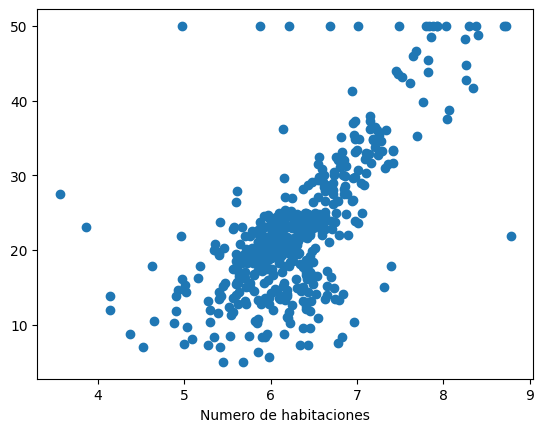

In [88]:
#definimos columna 5 del dataset, cantidad de habitaciones
x = boston[['RM']]
#columna a predecir, precio de la vivienda
y = boston['MEDV']

#graficamos los datos correspondientes
plt.scatter(x,y)
plt.xlabel('Numero de habitaciones')
plt.show()


In [89]:
#####IMPLEMENTACION DE LA REGRESION LINEAL SIMPLE ####

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#separo los datos de train en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
lr = linear_model.LinearRegression()

#Entreno el modelo
lr.fit(x_train, y_train)

# extra-Predicciones sobre TRAIN
y_pred_train = lr.predict(x_train)

#Realizo una prediccion
y_pred = lr.predict(x_test)

r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)



print(f"Pendiente (coef):  {lr.coef_[0]:.4f}")
print(f"Intercepto:        {lr.intercept_:.4f}")
print(f"MSE:               {mean_squared_error(y_test, y_pred):.4f}")
print(f"R²:                {r2_test:.4f}")
print(f"R²train:           {r2_train:.4f}")
print(f"Diferencia: {r2_train - r2_test:.4f}")


Pendiente (coef):  9.0521
Intercepto:        -34.2483
MSE:               40.1231
R²:                0.5634
R²train:           0.4607
Diferencia: -0.1027


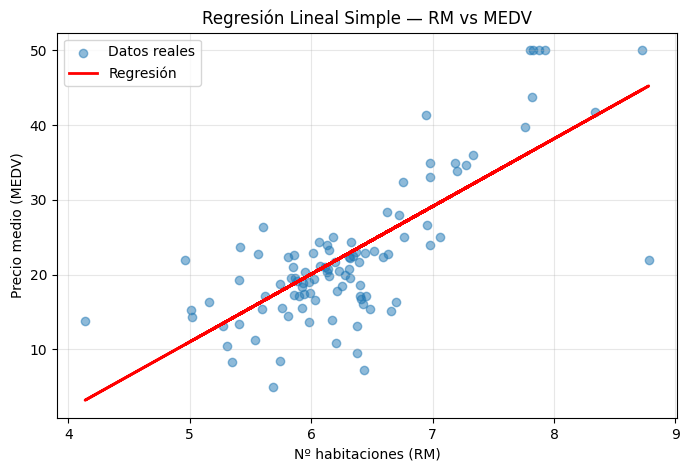

In [90]:
plt.figure(figsize=(8, 5))
plt.scatter(x_test, y_test, alpha=0.5, label='Datos reales')
plt.plot(x_test, y_pred, color='red', linewidth=2, label='Regresión')
plt.xlabel('Nº habitaciones (RM)')
plt.ylabel('Precio medio (MEDV)')
plt.title('Regresión Lineal Simple — RM vs MEDV')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

DATOS DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE - REALES VS PREDICHOS
📊 COMPARACIÓN REAL vs PREDICHO (primeras 10 filas):
   Real (y_test)  Predicho (y_pred)  Error  Error_abs
0           27.5              24.64   2.86       2.86
1           29.9              26.76   3.14       3.14
2           22.8              17.90   4.90       4.90
3           10.5              16.98  -6.48       6.48
4           19.1              19.98  -0.88       0.88
5           19.9              20.57  -0.67       0.67
6           30.7              27.25   3.45       3.45
7           18.0              21.26  -3.26       3.26
8           27.5              25.18   2.32       2.32
9           23.6              22.31   1.29       1.29

📈 COEFICIENTES DEL MODELO
  RM      : +8.0054
  AGE     : -0.1024
  DIS     : -0.3941
  Intercepto: -19.3900

  Ecuación: MEDV = 8.0054·RM + -0.1024·AGE + -0.3941·DIS -19.3900

📊 MÉTRICAS DEL MODELO
  R² Train:      0.5249
  R² Test:       0.5706
  Diferencia:    -0.0457
  MSE Test:  

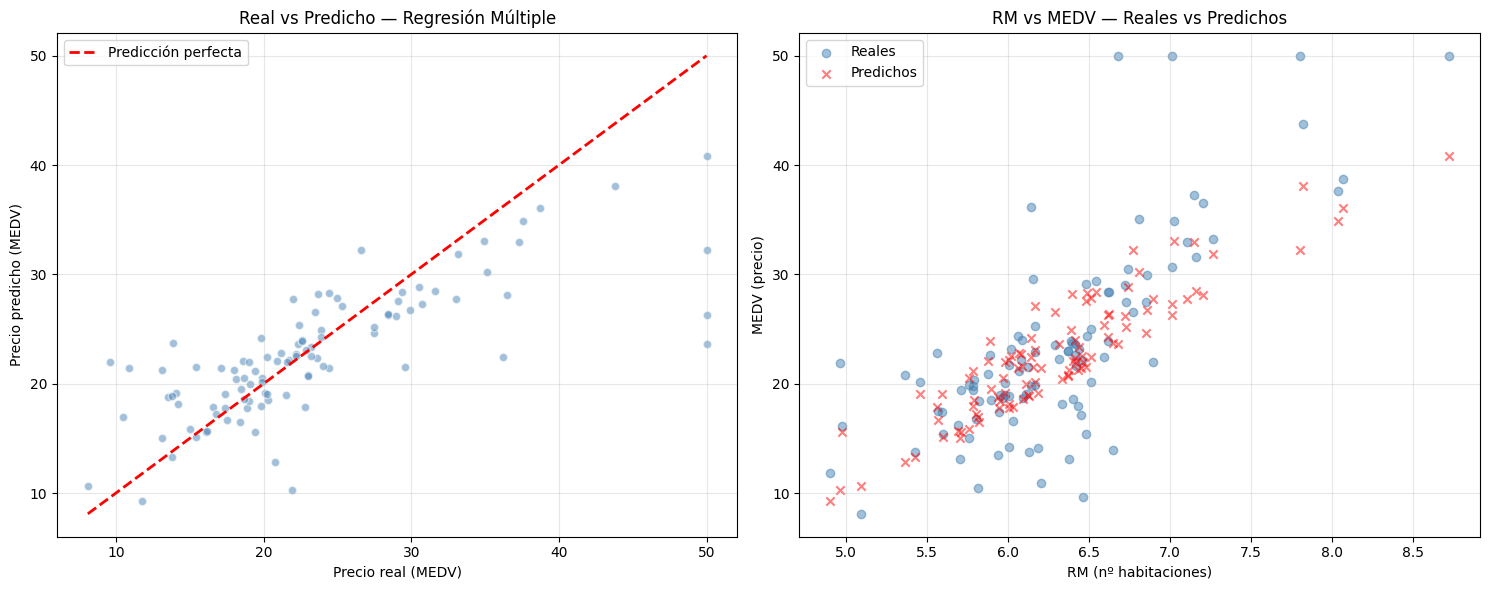

In [91]:
x_multiple = boston[['RM', 'AGE', 'DIS']]

#print(x_multiple)

x_train, x_test, y_train, y_test = train_test_split(x_multiple, y, test_size=0.2)

lr_multiple = linear_model.LinearRegression()

lr_multiple.fit(x_train, y_train)

# ------------------------------------------------------------
# 4. Predicciones (con los nombres que pediste)
# ------------------------------------------------------------
y_pred_multiple_train = lr_multiple.predict(x_train)   # ← predicciones sobre TRAIN
y_pred_multiple       = lr_multiple.predict(x_test)    # ← predicciones sobre TEST

# ------------------------------------------------------------
# 5. Tabla comparativa Real vs Predicho (test)
# ------------------------------------------------------------
print("DATOS DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE - REALES VS PREDICHOS")

comparacion = pd.DataFrame({
    'Real (y_test)':     y_test.values,
    'Predicho (y_pred)': y_pred_multiple,
    'Error':             y_test.values - y_pred_multiple,
    'Error_abs':         np.abs(y_test.values - y_pred_multiple)
}).round(2)

print("📊 COMPARACIÓN REAL vs PREDICHO (primeras 10 filas):")
print(comparacion.head(10))
print()

# ------------------------------------------------------------
# 6. Coeficientes del modelo (¡3 coeficientes, no 1!)
# ------------------------------------------------------------
print("=" * 55)
print("📈 COEFICIENTES DEL MODELO")
print("=" * 55)
for nombre, coef in zip(x_multiple.columns, lr_multiple.coef_):
    print(f"  {nombre:8s}: {coef:+.4f}")
print(f"  {'Intercepto':8s}: {lr_multiple.intercept_:+.4f}")
print()
print(f"  Ecuación: MEDV = {lr_multiple.coef_[0]:.4f}·RM + "
      f"{lr_multiple.coef_[1]:.4f}·AGE + {lr_multiple.coef_[2]:.4f}·DIS "
      f"{lr_multiple.intercept_:+.4f}")
print("=" * 55)

# ------------------------------------------------------------
# 7. Métricas (usando los nombres actualizados)
# ------------------------------------------------------------
r2_train  = r2_score(y_train, y_pred_multiple_train)   # ← R² train
r2_test   = r2_score(y_test,  y_pred_multiple)         # ← R² test
mse_test  = mean_squared_error(y_test, y_pred_multiple)
rmse_test = np.sqrt(mse_test)

print()
print("=" * 55)
print("📊 MÉTRICAS DEL MODELO")
print("=" * 55)
print(f"  R² Train:      {r2_train:.4f}")
print(f"  R² Test:       {r2_test:.4f}")
print(f"  Diferencia:    {r2_train - r2_test:+.4f}")
print(f"  MSE Test:      {mse_test:.4f}")
print(f"  RMSE Test:     {rmse_test:.4f}  (±${rmse_test*1000:,.0f})")
print("=" * 55)

# Diagnóstico
diff = r2_train - r2_test
if diff > 0.10:
    print("🚨 OVERFITTING")
elif r2_train < 0.5 and r2_test < 0.5:
    print("❌ UNDERFITTING")
else:
    print("✅ BUEN AJUSTE")

# ------------------------------------------------------------
# 8. Gráficos (2 en 1)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfico 1: Predicho vs Real (el estándar en múltiple) ---
axes[0].scatter(y_test, y_pred_multiple, alpha=0.5, color='steelblue', edgecolor='white')

# Línea ideal (y = x)
minv = min(y_test.min(), y_pred_multiple.min())
maxv = max(y_test.max(), y_pred_multiple.max())
axes[0].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Predicción perfecta')

axes[0].set_xlabel('Precio real (MEDV)')
axes[0].set_ylabel('Precio predicho (MEDV)')
axes[0].set_title('Real vs Predicho — Regresión Múltiple')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Gráfico 2: RM vs MEDV (una sola feature) con predicciones ---
axes[1].scatter(x_test['RM'], y_test, alpha=0.5, color='steelblue',
                label='Reales')
axes[1].scatter(x_test['RM'], y_pred_multiple, alpha=0.5, color='red',
                marker='x', label='Predichos')

axes[1].set_xlabel('RM (nº habitaciones)')
axes[1].set_ylabel('MEDV (precio)')
axes[1].set_title('RM vs MEDV — Reales vs Predichos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()